# STINTSY Project

### De La Salle University

## Authors

- Ian De Jesus
- Jeff Valerio Fonte
- Ponj Elazegui
- Raine Villaver

### Date:

---
## Table Of Contents 

---
## Introduction

---
## Dataset Description  

The dataset used in this project is loaded from [`Dataset.csv`](https://raw.githubusercontent.com/rainev/Bean_Dataset/refs/heads/main/Dataset.csv). It contains 13,610 bean samples, where each row represents one dry bean instance described by 16 numerical features and 1 target label.

The numerical attributes capture image-derived size and shape measurements such as `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `Eccentricity`, `ConvexArea`, `EquivDiameter`, `Solidity`, `roundness`, `Compactness`, and the `ShapeFactor` variables. The target column, `Class`, identifies the bean variety.

There are 7 bean classes in the dataset: `BARBUNYA`, `BOMBAY`, `CALI`, `DERMASON`, `HOROZ`, `SEKER`, and `SIRA`. This makes the dataset suitable for supervised multiclass classification and exploratory analysis of morphological differences between bean varieties.

---

## Required Libraries

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Reading the Dataset

The dataset is retrieved from a CSV file hosted on the project's [GitHub repository](https://github.com/rainev/Bean_Dataset/tree/main). We use the `pandas.read_csv` function to load the data into a DataFrame object named `df`. This DataFrame will be used for further analysis throughout this project.

In [29]:
df = pd.read_csv('https://raw.githubusercontent.com/rainev/Bean_Dataset/refs/heads/main/Dataset.csv')

The `info()` function displays general information about the dataset.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

### Reviewing the Values of Each Feature
We review the unique values of each column in the dataset to gain an initial understanding of its contents. This step helps in identifying potential inconsistencies, such as repeated values or unexpected categories, and ensures that the data is as expected before moving on to further analysis or cleaning.

In [31]:
with np.printoptions(threshold=75):
    for col in df.columns:
        print(f"Unique values for column '{col}':")
        print(np.sort(df[col].unique()))            # Sort and print the unique values in the column
        print("=" * 50)

Unique values for column 'Area':
[ 20420  20464  20548 ... 248424 251432 254616]
Unique values for column 'Perimeter':
[ 524.736  524.932  525.413 ... 1919.868 1921.685 1985.37 ]
Unique values for column 'MajorAxisLength':
[183.601165  183.9652515 185.3819214 ... 726.3734932 738.1445017
 738.8601535]
Unique values for column 'MinorAxisLength':
[122.5126535 129.5762069 129.7481935 ... 449.3396784 450.9261867
 460.1984968]
Unique values for column 'AspectRation':
[1.0248676  1.03642268 1.0419637  ... 2.38739489 2.38887344 2.43030645]
Unique values for column 'Eccentricity':
[0.21895126 0.26277438 0.28093659 ... 0.90804778 0.90816732 0.91142297]
Unique values for column 'ConvexArea':
[ 20684  20772  20825 ... 251082 257425 263261]
Unique values for column 'EquivDiameter':
[161.2437642 161.4173908 161.7483421 ... 562.4084465 565.8031152
 569.3743583]
Unique values for column 'Extent':
[0.55531472 0.56666925 0.56676753 ... 0.85284143 0.85841985 0.86619464]
Unique values for column 'Solidity

In [32]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [35]:
df['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

---

## Model Selection

---

## Model Evaluation

---
## Initial Data Preprocessing

In [36]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


### Checking for Duplicate Rows

The dataset is also checked for duplicate rows to identify repeated observations. Duplicate entries may bias the model, so they should be removed when necessary.

In [37]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
68


### Removing Duplicate Rows

If duplicate rows are found, they are removed to improve the quality and consistency of the dataset.

In [38]:
df = df.drop_duplicates()

### Checking for Malformed Data Entry and Line-Ending Issues

Before modeling, the target labels are checked for hidden spaces or carriage-return characters that may create inconsistent class names. The `Class` column is cleaned in place using `str.strip()` so that only one standardized target column is kept for the rest of the workflow.

In [49]:
print("Raw unique classes: ", df["Class"].nunique())

Raw unique classes:  7


In [50]:
df["Class"] = df["Class"].astype(str).str.strip()

In [51]:
print("Cleaned unique classes:", df["Class"].nunique())
print(df["Class"].value_counts())

Cleaned unique classes: 7
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


### Separating Features and Target Variable

The predictor variables are separated from the target variable. In this dataset, the input features are the numerical bean measurements, while the target variable is the cleaned `Class` column. Removing only `Class` from `X` prevents the target labels from being included as model inputs.

In [39]:
X = df.drop("Class", axis=1)
y = df["Class"]

### Encoding the Target Variable

Since the target variable contains categorical labels, it must be converted into numerical form so that machine learning algorithms can process it.

In [40]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

### Splitting the Dataset

The dataset is divided into training and testing sets. This allows the model to learn from one portion of the data and be evaluated on a separate unseen portion.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### Scaling the Features

Feature scaling is applied so that all numerical variables are placed on a comparable scale. This is especially useful for models that are sensitive to differences in feature magnitude.

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Viewing the Processed Data Shapes

The shapes of the training and testing sets are displayed to confirm that the preprocessing steps were completed successfully.

In [46]:
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (10834, 16)
Testing set shape: (2709, 16)


---

## Exploratory Data Analysis

This section aims to provide a better understanding of the data through visualizations and summary statistics, exploring distributions and identifying relationships between variables.

We begin by examining the distribution of bean samples across classes. This helps determine whether the dataset is balanced and highlights which classes may be underrepresented during model training.

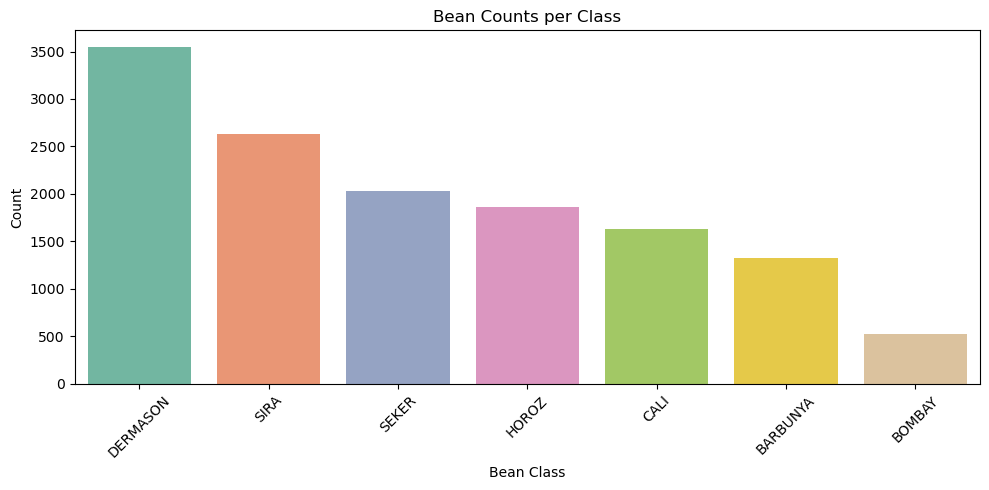

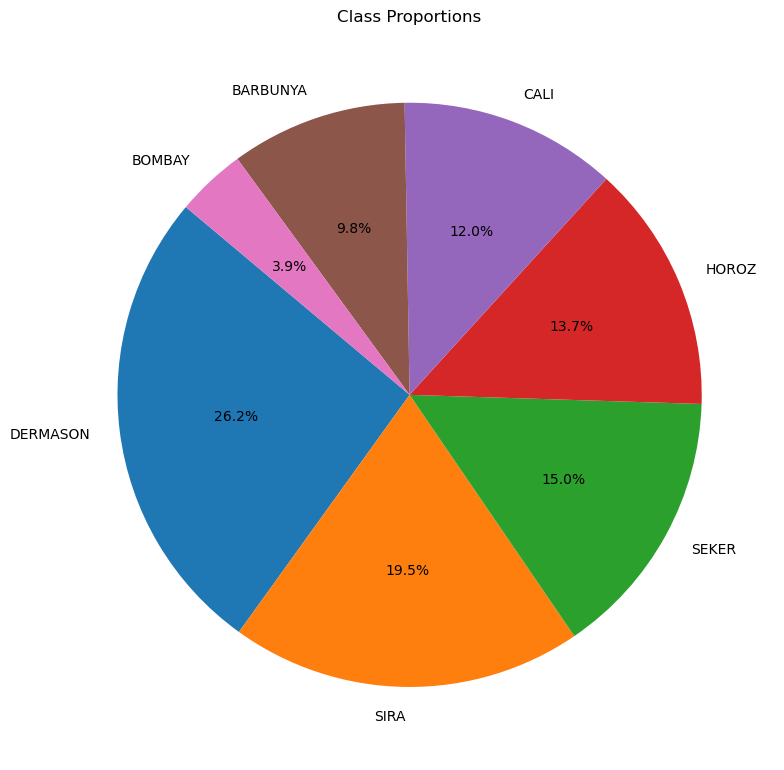

In [73]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated and will be removed in a future version.*",
    category=FutureWarning
)

class_counts = df["Class"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")
plt.title("Bean Counts per Class")
plt.xlabel("Bean Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Class Proportions")
plt.tight_layout()
plt.show()

### Interpretation of Class Distribution

The bar chart and pie chart show that the dataset is not balanced across bean classes. `DERMASON` has the largest number of samples, while `BOMBAY` has the smallest. This class imbalance should be considered during model development, since models may perform better on majority classes than on minority classes if evaluation is based only on overall accuracy.

### Distribution of Key Bean Features

To better understand the physical characteristics of the beans, we examine the distributions of seven important continuous features: `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `Eccentricity`, `roundness`, and `Compactness`.

Histograms are used to see how values are spread across the whole dataset, including where values are concentrated and whether the distribution is skewed. Density plots provide a smoother view of the same overall distribution, making peaks and tails easier to notice. Boxplots grouped by `Class` are included to compare the same feature across bean varieties, helping identify differences in median values, variability, and potential outliers.

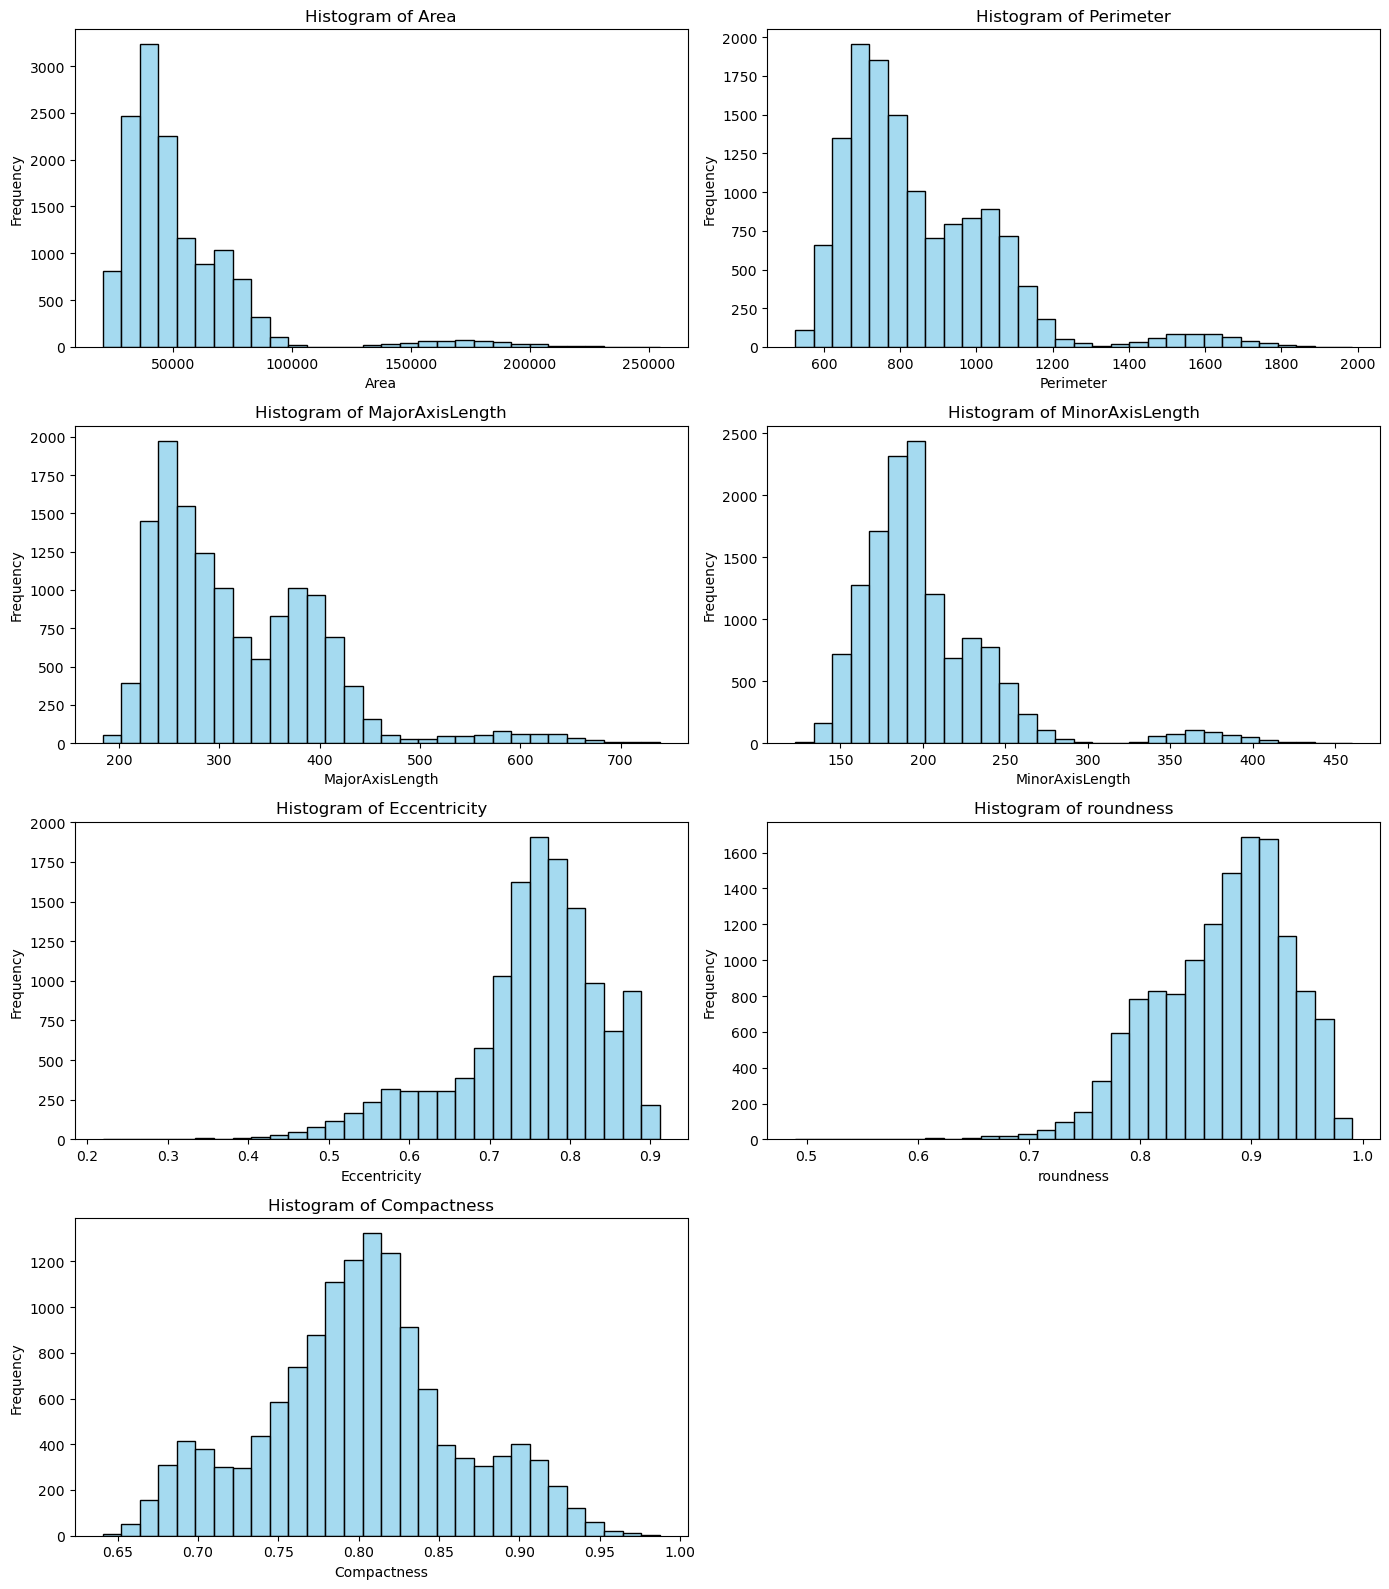

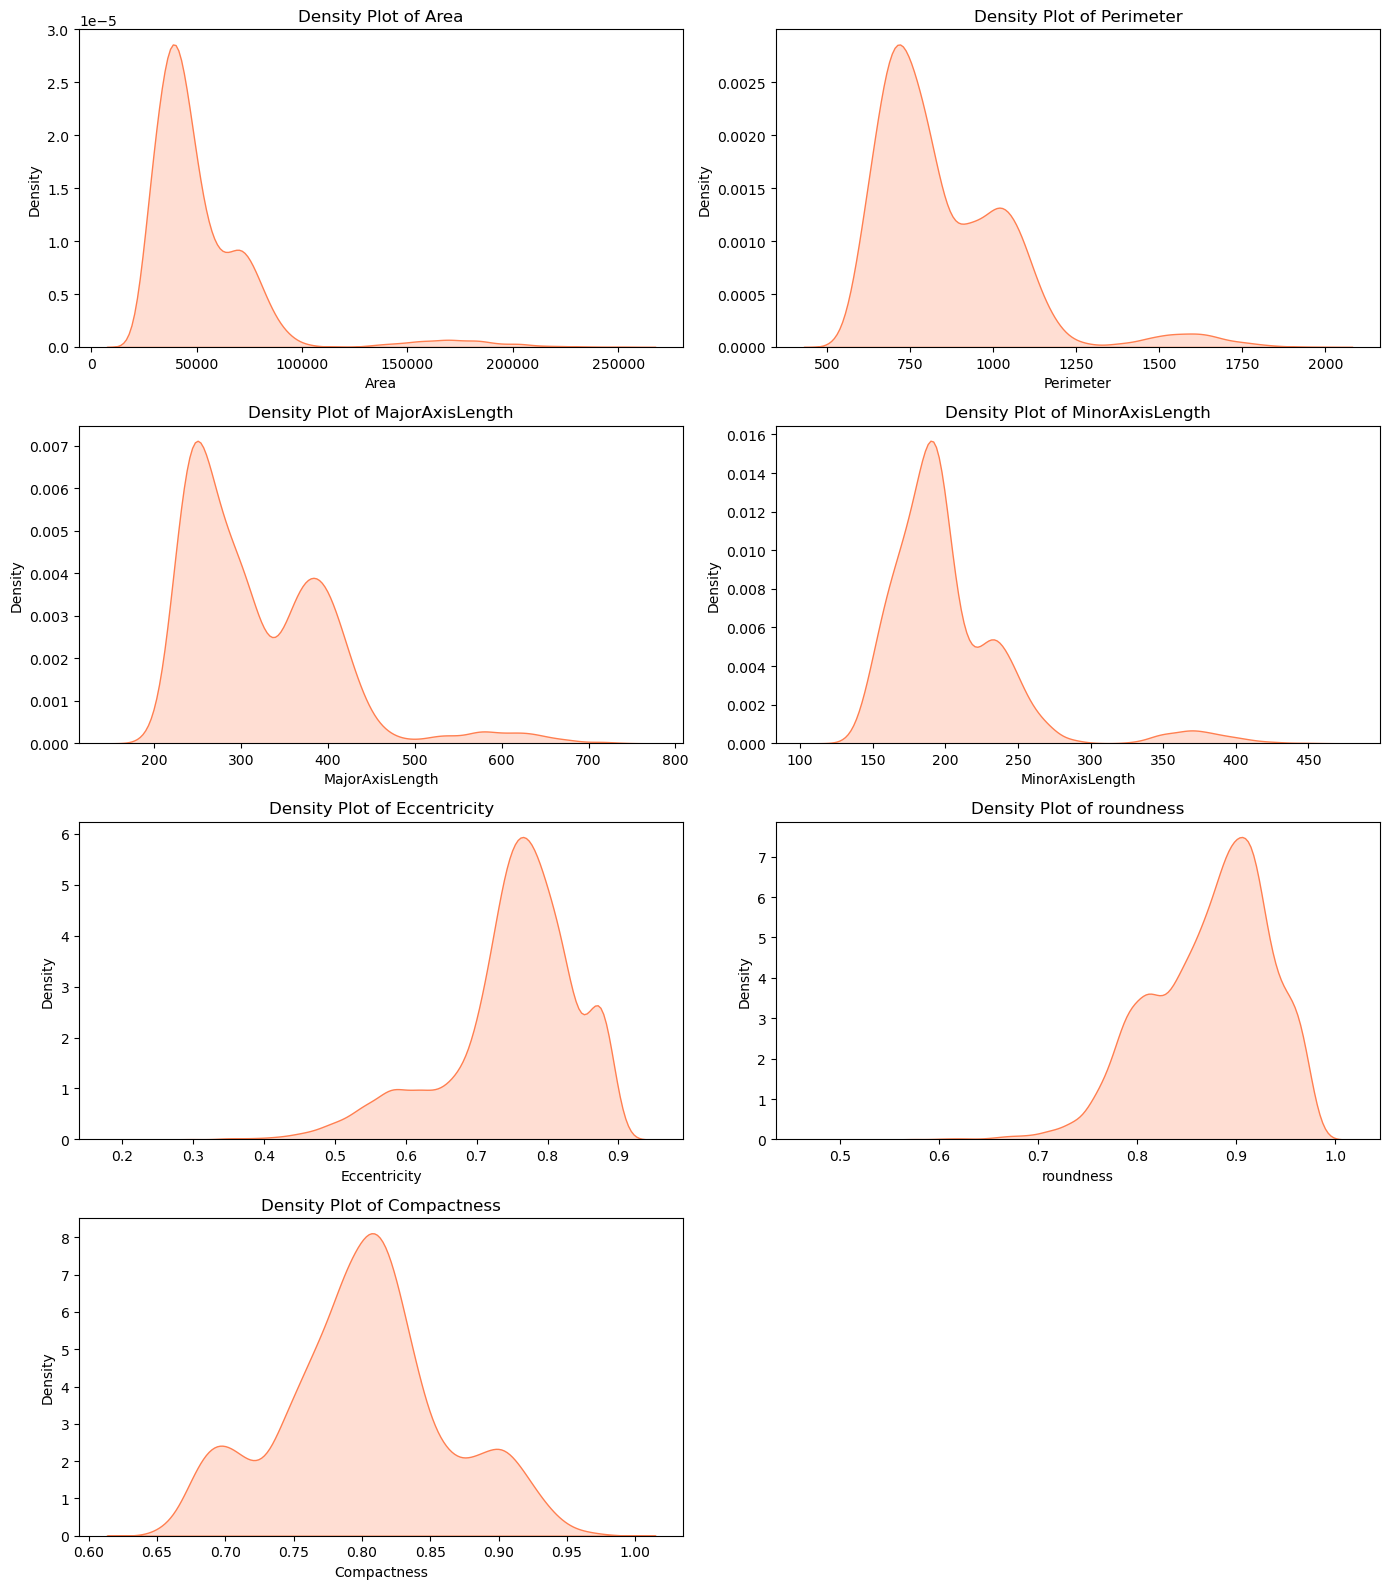

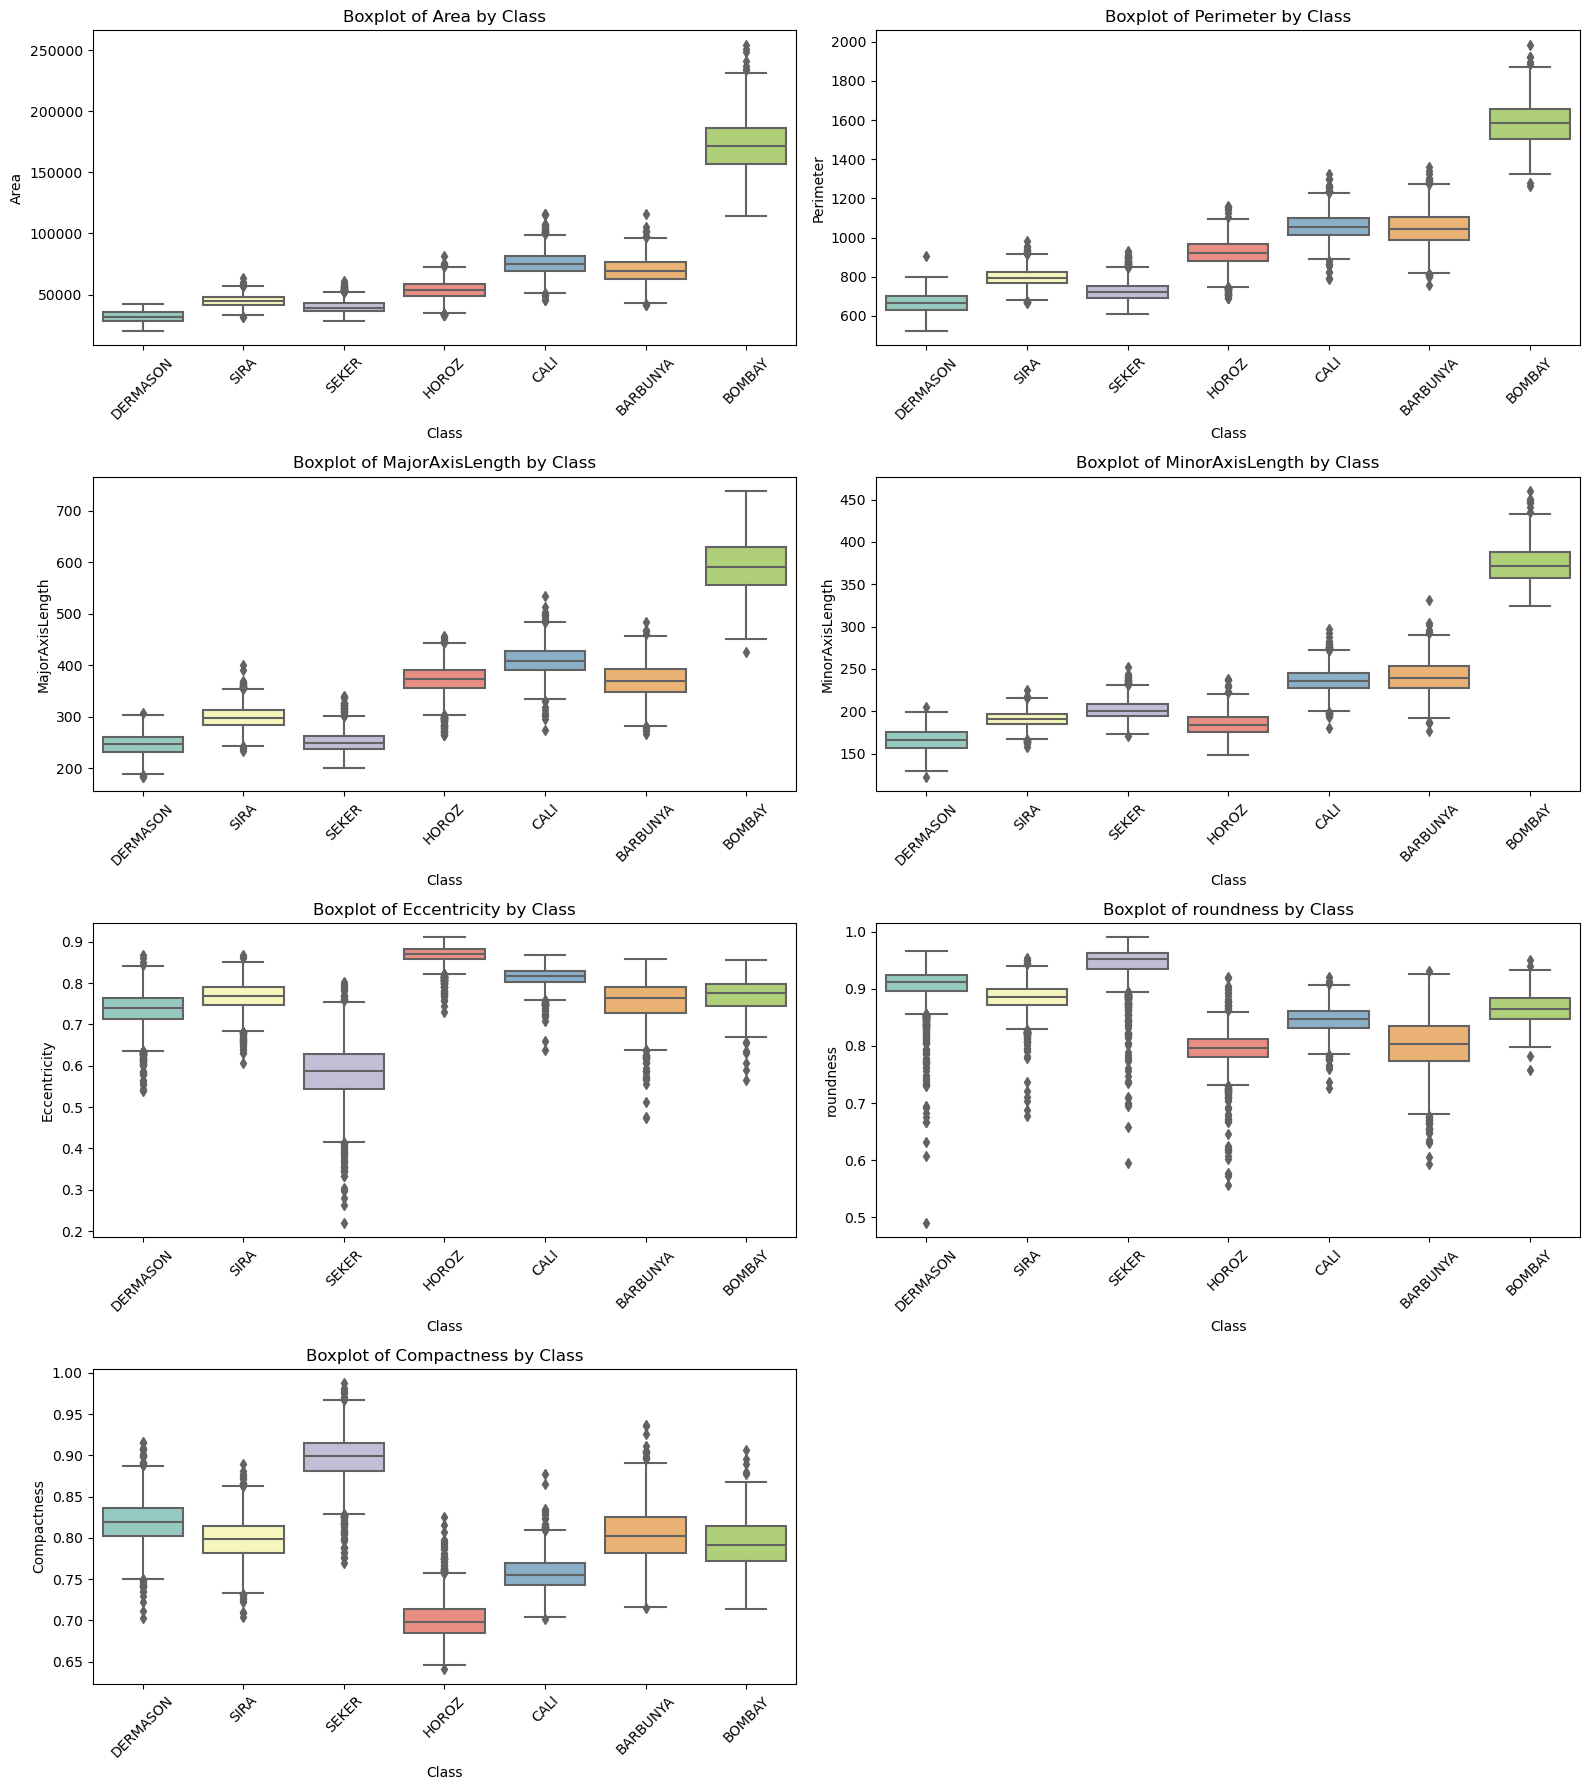

In [75]:
feature_columns = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "Eccentricity",
    "roundness",
    "Compactness"
]

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated and will be removed in a future version.*",
    category=FutureWarning
)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):
    sns.histplot(df[feature], bins=30, kde=False, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Histogram of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):
    sns.kdeplot(data=df, x=feature, fill=True, ax=axes[i], color="coral")
    axes[i].set_title(f"Density Plot of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
axes = axes.flatten()

class_order = df["Class"].value_counts().index

for i, feature in enumerate(feature_columns):
    sns.boxplot(data=df, x="Class", y=feature, order=class_order, ax=axes[i], palette="Set3")
    axes[i].set_title(f"Boxplot of {feature} by Class")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis="x", rotation=45)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Interpretation of Feature Distributions

The histograms and density plots summarize the overall behavior of each numerical feature across all bean samples. These plots are useful for understanding the general shape of the data before building models, such as whether a feature has a wide range, clusters around certain values, or appears skewed.

The boxplots are more useful for class comparison because they show how each feature differs across bean classes. Features such as `Area`, `Perimeter`, `MajorAxisLength`, and `MinorAxisLength` are expected to show clearer separation because they directly describe bean size. Shape-related measures such as `Eccentricity`, `roundness`, and `Compactness` can reveal differences in bean form, which may also contribute to class discrimination.

### Correlation Between Numerical Features

After examining the individual feature distributions, the next step is to study how the numerical features relate to one another. A correlation heatmap helps identify strongly related variables, which is useful for understanding redundancy among measurements and for interpreting which bean properties tend to increase or decrease together.

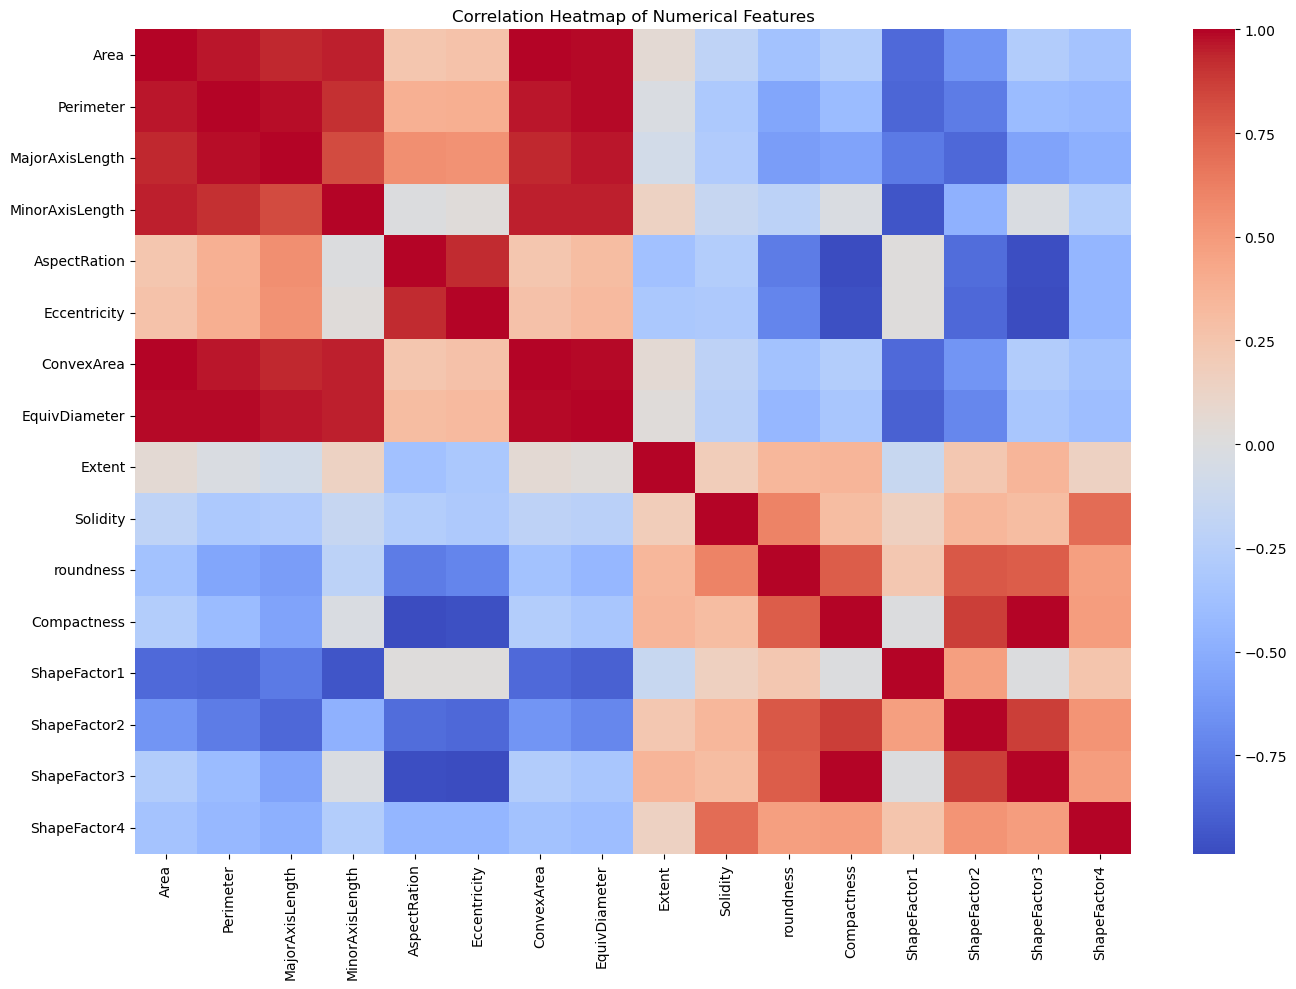

In [76]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.drop(columns=["Class"]).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Interpretation of Correlation Heatmap

The correlation heatmap shows the strength and direction of relationships between pairs of numerical features. Strong positive correlations suggest that some measurements capture similar information, especially among size-related variables such as `Area`, `Perimeter`, and the axis lengths. This is useful in EDA because it shows which features move together and which ones may provide distinct information for classification.

### Scatter Plots for Class Separation

Scatter plots are used to examine how pairs of features interact while showing the bean class through color. Unlike the earlier histograms and density plots, these visualizations make it easier to see whether certain bean varieties form visible clusters or overlap with one another in feature space.

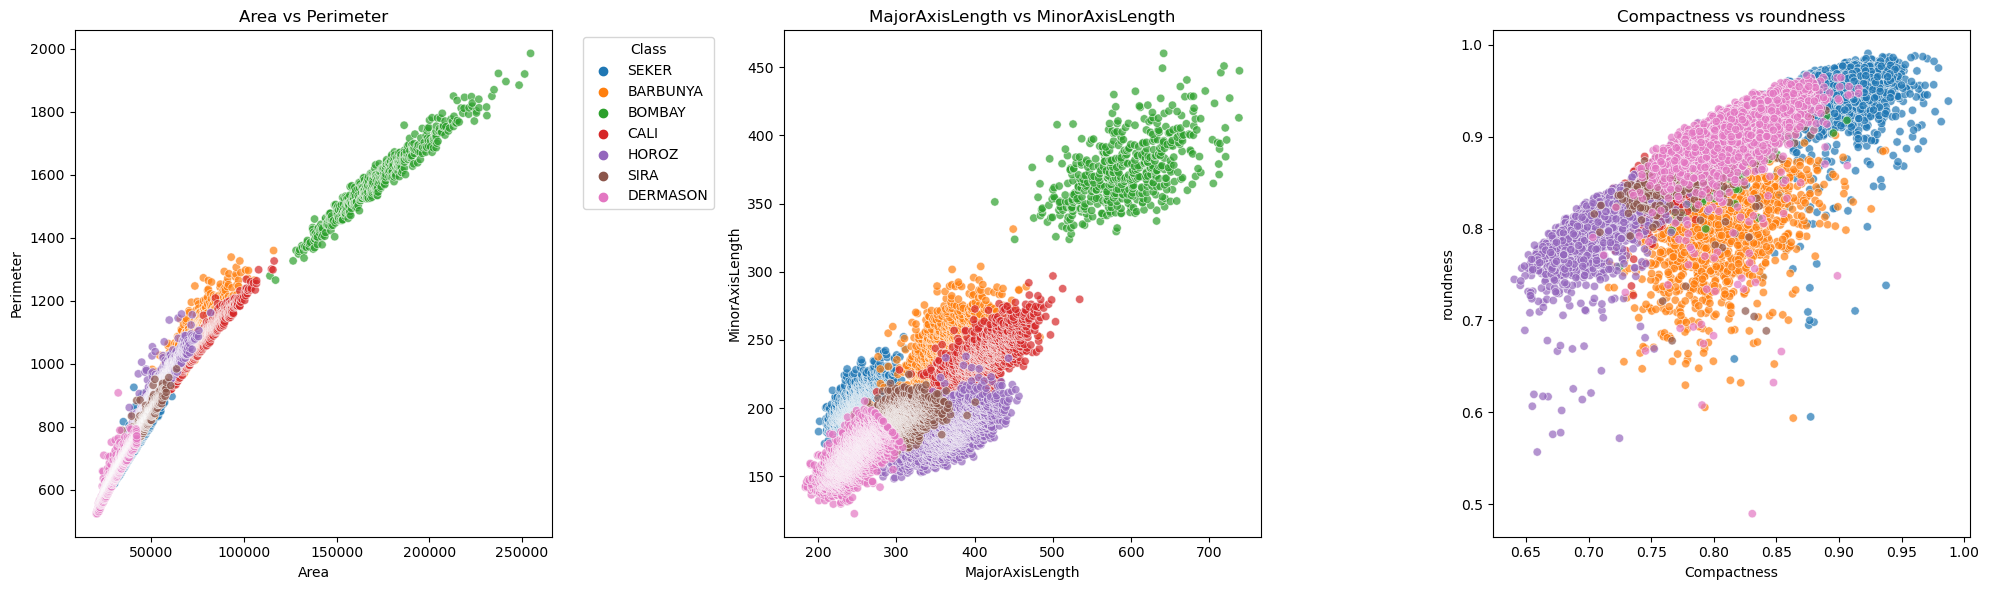

In [77]:
scatter_pairs = [
    ("Area", "Perimeter"),
    ("MajorAxisLength", "MinorAxisLength"),
    ("Compactness", "roundness")
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (x_feature, y_feature) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue="Class",
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f"{x_feature} vs {y_feature}")
    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")

for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

### Interpretation of Scatter Plots

These scatter plots help assess class separability by showing whether bean classes cluster in different regions when two features are considered together. Pairs such as `Area` and `Perimeter`, or `MajorAxisLength` and `MinorAxisLength`, are especially useful because they combine related size measurements. If classes show visible grouping, these features are likely to be informative for the classification models that follow.